<a href="https://colab.research.google.com/github/DarshaPadmanban/24ADI003_24BAD017/blob/main/24BAD017_ML_EXP_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (43084, 4)

Sample Data:
    userId  movieId  rating    timestamp
0       1        1     4.0  964982703.0
1       1        3     4.0  964981247.0
2       1        6     4.0  964982224.0
3       1       47     5.0  964983815.0
4       1       50     5.0  964982931.0

Unique Users: 288
Unique Movies: 6433

User-Item Matrix Shape: (288, 6433)

Mean rating of first 5 users:
 userId
1    0.157469
2    0.017799
3    0.014768
4    0.119384
5    0.024872
dtype: float64

Shapes after SVD:
U: (288, 288)
Sigma: (288,)
Vt: (288, 6433)

----- Using k = 10 latent factors -----
RMSE: 2.5292320973625624
MAE: 2.2064568021919864

----- Using k = 20 latent factors -----
RMSE: 2.280380315141463
MAE: 1.8658464670759376

----- Using k = 50 latent factors -----
RMSE: 1.759433738858701
MAE: 1.2277156975582488

Top Recommendations for User 1:
 movieId
2355    1.799343
588     1.641437
1907    1.509688
1200    1.433119
2167    1.311272
Name: 1, dtype: float64

===== Performance Table =====
k = 10

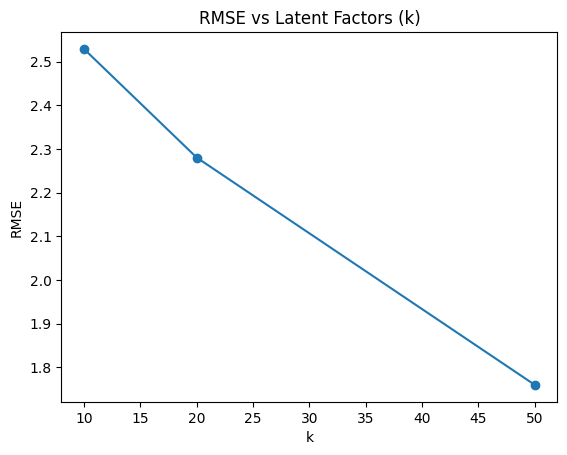

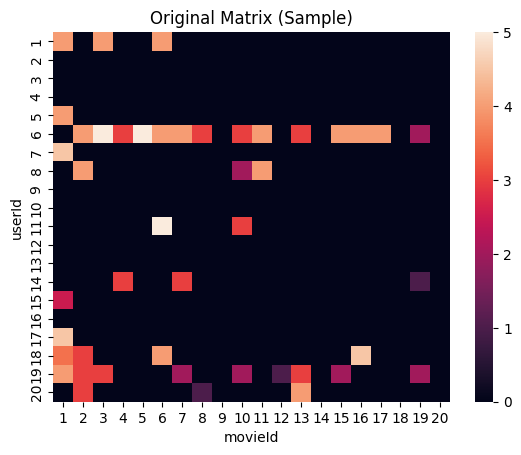

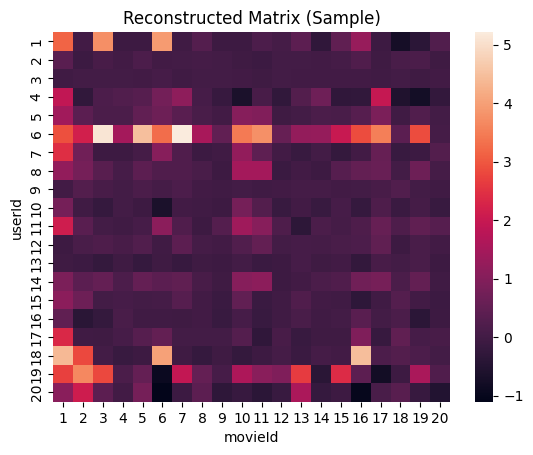

In [ ]:

import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

ratings = pd.read_csv("ratings.csv")

print("Dataset Shape:", ratings.shape)
print("\nSample Data:\n", ratings.head())

ratings = ratings[['userId', 'movieId', 'rating']]

print("\nUnique Users:", ratings['userId'].nunique())
print("Unique Movies:", ratings['movieId'].nunique())

user_item_matrix = ratings.pivot(index='userId', columns='movieId', values='rating')

print("\nUser-Item Matrix Shape:", user_item_matrix.shape)

matrix_filled = user_item_matrix.fillna(0)

user_mean = np.mean(matrix_filled, axis=1)
matrix_norm = matrix_filled.sub(user_mean, axis=0)

print("\nMean rating of first 5 users:\n", user_mean.head())

U, sigma, Vt = np.linalg.svd(matrix_norm, full_matrices=False)

print("\nShapes after SVD:")
print("U:", U.shape)
print("Sigma:", sigma.shape)
print("Vt:", Vt.shape)

k_values = [10, 20, 50]
results = []

for k in k_values:
    print(f"\n----- Using k = {k} latent factors -----")

    sigma_k = np.diag(sigma[:k])
    U_k = U[:, :k]
    Vt_k = Vt[:k, :]

    reconstructed = np.dot(np.dot(U_k, sigma_k), Vt_k)

    reconstructed = reconstructed + user_mean.values.reshape(-1, 1)

    pred_df = pd.DataFrame(reconstructed,
                           index=user_item_matrix.index,
                           columns=user_item_matrix.columns)

    actual = user_item_matrix.values[user_item_matrix.notna()]
    predicted = pred_df.values[user_item_matrix.notna()]

    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)

    print("RMSE:", rmse)
    print("MAE:", mae)

    results.append((k, rmse, mae))

def recommend_movies(user_id, n=5):
    user_row = pred_df.loc[user_id]
    already_rated = user_item_matrix.loc[user_id].dropna().index

    recommendations = user_row.drop(already_rated).sort_values(ascending=False).head(n)

    return recommendations

print("\nTop Recommendations for User 1:\n", recommend_movies(1, 5))

k_list, rmse_list, mae_list = zip(*results)

print("\n===== Performance Table =====")
for i in range(len(k_list)):
    print(f"k = {k_list[i]}  |  RMSE = {rmse_list[i]:.4f}  |  MAE = {mae_list[i]:.4f}")


print("\n===== Predicted vs Actual Ratings (Sample) =====")

rows, cols = np.where(~np.isnan(user_item_matrix.values))

for i in range(10):
    r = rows[i]
    c = cols[i]

    actual_val = user_item_matrix.values[r, c]
    predicted_val = pred_df.values[r, c]

    print(f"User {user_item_matrix.index[r]}, Movie {user_item_matrix.columns[c]} -> Actual: {actual_val}, Predicted: {predicted_val:.2f}")



print("\nOriginal Matrix Size:", matrix_norm.shape)
print("Reduced Matrix Size (k=50):", U_k.shape, sigma_k.shape, Vt_k.shape)

plt.figure()
plt.plot(k_list, rmse_list, marker='o')
plt.title("RMSE vs Latent Factors (k)")
plt.xlabel("k")
plt.ylabel("RMSE")
plt.show()

plt.figure()
sns.heatmap(matrix_filled.iloc[:20, :20])
plt.title("Original Matrix (Sample)")
plt.show()

plt.figure()
sns.heatmap(pred_df.iloc[:20, :20])
plt.title("Reconstructed Matrix (Sample)")
plt.show()

Dataset Shape: (100836, 4)

Sample Data:
    userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931

Unique Users: 610
Unique Movies: 9724

User-Item Matrix Shape: (610, 9724)

Matrix Sparsity: 0.983

===== Using k = 10 latent factors =====


/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


User-feature matrix (W) shape: (610, 10)
Item-feature matrix (H) shape: (10, 9724)
RMSE: 2.6170386338033884
Precision@5: 0.584
Recall@5: 0.0562

===== Using k = 20 latent factors =====
User-feature matrix (W) shape: (610, 20)
Item-feature matrix (H) shape: (20, 9724)
RMSE: 2.4588660650487144
Precision@5: 0.612
Recall@5: 0.0652

===== Using k = 50 latent factors =====


/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


User-feature matrix (W) shape: (610, 50)
Item-feature matrix (H) shape: (50, 9724)
RMSE: 2.1617658322512825
Precision@5: 0.664
Recall@5: 0.0672

===== Top Recommendations for User 1 =====
movieId
1200    3.959236
589     3.544807
1374    3.430519
1387    3.191126
541     3.171203
Name: 1, dtype: float64

===== Performance Table =====
k = 10 | RMSE = 2.6170 | Precision@5 = 0.5840 | Recall@5 = 0.0562
k = 20 | RMSE = 2.4589 | Precision@5 = 0.6120 | Recall@5 = 0.0652
k = 50 | RMSE = 2.1618 | Precision@5 = 0.6640 | Recall@5 = 0.0672

===== Predicted vs Actual Ratings (Sample) =====
User 1, Movie 1 -> Actual: 4.0, Predicted: 1.91
User 1, Movie 3 -> Actual: 4.0, Predicted: 0.66
User 1, Movie 6 -> Actual: 4.0, Predicted: 2.09
User 1, Movie 47 -> Actual: 5.0, Predicted: 2.96
User 1, Movie 50 -> Actual: 5.0, Predicted: 2.48
User 1, Movie 70 -> Actual: 3.0, Predicted: 1.54
User 1, Movie 101 -> Actual: 5.0, Predicted: 0.96
User 1, Movie 110 -> Actual: 4.0, Predicted: 2.78
User 1, Movie 151 -> Actu

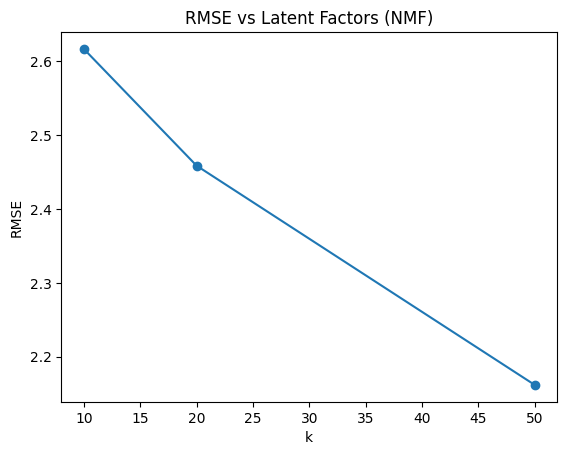

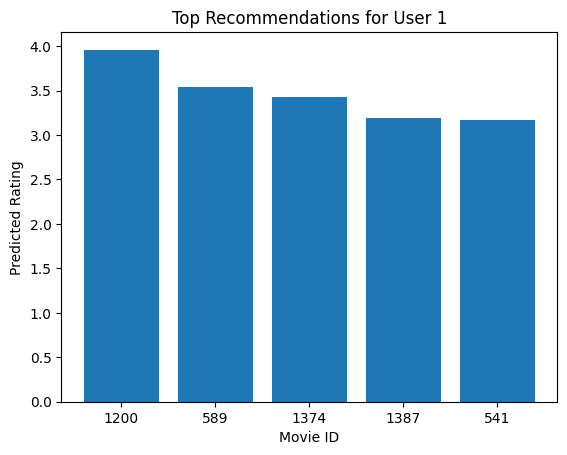

In [ ]:

import numpy as np
import pandas as pd
from sklearn.decomposition import NMF
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt


ratings = pd.read_csv("ratings.csv")

print("Dataset Shape:", ratings.shape)
print("\nSample Data:\n", ratings.head())


ratings = ratings[['userId', 'movieId', 'rating']]

user_item_matrix = ratings.pivot(index='userId', columns='movieId', values='rating')

print("\nUnique Users:", ratings['userId'].nunique())
print("Unique Movies:", ratings['movieId'].nunique())
print("\nUser-Item Matrix Shape:", user_item_matrix.shape)

matrix_filled = user_item_matrix.fillna(0)

sparsity = 1.0 - np.count_nonzero(matrix_filled.values) / matrix_filled.size
print("\nMatrix Sparsity:", round(sparsity, 4))


k_values = [10, 20, 50]

results = []

for k in k_values:
    print(f"\n===== Using k = {k} latent factors =====")

    nmf_model = NMF(n_components=k, init='random', random_state=42, max_iter=200)


    W = nmf_model.fit_transform(matrix_filled)
    H = nmf_model.components_

    print("User-feature matrix (W) shape:", W.shape)
    print("Item-feature matrix (H) shape:", H.shape)


    reconstructed = np.dot(W, H)

    pred_df = pd.DataFrame(reconstructed,
                           index=user_item_matrix.index,
                           columns=user_item_matrix.columns)

    actual = user_item_matrix.values[user_item_matrix.notna()]
    predicted = pred_df.values[user_item_matrix.notna()]

    rmse = np.sqrt(mean_squared_error(actual, predicted))
    print("RMSE:", rmse)


    def precision_recall_at_k(user_id, k_recs=5, threshold=3.5):
        user_actual = user_item_matrix.loc[user_id]
        user_pred = pred_df.loc[user_id]

        relevant = user_actual[user_actual >= threshold].index
        recommended = user_pred.sort_values(ascending=False).head(k_recs).index

        true_positive = len(set(recommended) & set(relevant))

        precision = true_positive / k_recs
        recall = true_positive / len(relevant) if len(relevant) > 0 else 0

        return precision, recall

    precisions = []
    recalls = []

    for user in user_item_matrix.index[:50]:
        p, r = precision_recall_at_k(user)
        precisions.append(p)
        recalls.append(r)

    avg_precision = np.mean(precisions)
    avg_recall = np.mean(recalls)

    print("Precision@5:", round(avg_precision, 4))
    print("Recall@5:", round(avg_recall, 4))

    results.append((k, rmse, avg_precision, avg_recall, pred_df))

def recommend_movies(user_id, pred_df, n=5):
    user_row = pred_df.loc[user_id]
    already_rated = user_item_matrix.loc[user_id].dropna().index

    recs = user_row.drop(already_rated).sort_values(ascending=False).head(n)
    return recs

best_model = results[-1][4]

print("\n===== Top Recommendations for User 1 =====")
print(recommend_movies(1, best_model, 5))

print("\n===== Performance Table =====")
for k, rmse, p, r, _ in results:
    print(f"k = {k} | RMSE = {rmse:.4f} | Precision@5 = {p:.4f} | Recall@5 = {r:.4f}")

print("\n===== Predicted vs Actual Ratings (Sample) =====")

rows, cols = np.where(~np.isnan(user_item_matrix.values))

for i in range(10):
    r = rows[i]
    c = cols[i]

    actual_val = user_item_matrix.values[r, c]
    predicted_val = best_model.values[r, c]

    print(f"User {user_item_matrix.index[r]}, Movie {user_item_matrix.columns[c]} -> Actual: {actual_val}, Predicted: {predicted_val:.2f}")

print("\nOriginal Matrix Size:", matrix_filled.shape)
print("Reduced Size (k=50):", results[-1][4].shape, "via W and H")

k_list = [x[0] for x in results]
rmse_list = [x[1] for x in results]

plt.figure()
plt.plot(k_list, rmse_list, marker='o')
plt.title("RMSE vs Latent Factors (NMF)")
plt.xlabel("k")
plt.ylabel("RMSE")
plt.show()
recs = recommend_movies(1, best_model, 5)

plt.figure()
plt.bar(range(len(recs)), recs.values)
plt.xticks(range(len(recs)), recs.index)
plt.title("Top Recommendations for User 1")
plt.xlabel("Movie ID")
plt.ylabel("Predicted Rating")
plt.show()